In [20]:
import numpy as np
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('bank_transactions_data_2.csv')
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [23]:
df.shape

(2512, 16)

In [24]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [25]:
df.head(10)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18,Student,172,1,781.68,2024-11-04 08:06:36
6,TX000007,AC00199,7.08,2023-02-15 16:36:48,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71,2024-11-04 08:10:09
7,TX000008,AC00069,171.42,2023-05-08 17:47:59,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24,2024-11-04 08:10:55
8,TX000009,AC00135,106.23,2023-03-21 16:59:46,Credit,Detroit,D000690,24.148.92.177,M035,Branch,51,Engineer,86,1,9095.14,2024-11-04 08:11:14
9,TX000010,AC00385,815.96,2023-03-31 16:06:57,Debit,Nashville,D000199,32.169.88.41,M007,ATM,55,Doctor,120,1,1021.88,2024-11-04 08:06:32


In [26]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [27]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512,2512,2512.000000,2512,2512,2512,2512,2512,2512,2512,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512
unique,2512,495,NaN,2512,2,43,681,592,100,3,NaN,4,NaN,NaN,NaN,360
top,TX002496,AC00460,NaN,2023-04-03 16:07:53,Debit,Fort Worth,D000548,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,1,12,NaN,1,1944,70,9,13,45,868,NaN,657,NaN,NaN,NaN,16
mean,NaN,NaN,297.593778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.673965,NaN,119.643312,1.124602,5114.302966,NaN
std,NaN,NaN,291.946243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.792198,NaN,69.963757,0.602662,3900.942499,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.885000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.370000,NaN
50%,NaN,NaN,211.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.500000,1.000000,4735.510000,NaN
75%,NaN,NaN,414.527500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7678.820000,NaN


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [29]:
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [30]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.nunique()

TransactionID              2512
AccountID                   495
TransactionAmount          2455
TransactionDate            2512
TransactionType               2
Location                     43
DeviceID                    681
IP Address                  592
MerchantID                  100
Channel                       3
CustomerAge                  63
CustomerOccupation            4
TransactionDuration         288
LoginAttempts                 5
AccountBalance             2510
PreviousTransactionDate     360
dtype: int64

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [34]:
df['Location'].value_counts()

Location
Fort Worth          70
Los Angeles         69
Oklahoma City       68
Charlotte           68
Philadelphia        67
Tucson              67
Omaha               65
Miami               64
Memphis             63
Detroit             63
Houston             63
Denver              62
Kansas City         61
Boston              61
Seattle             61
Mesa                61
Atlanta             61
Fresno              60
Chicago             60
Colorado Springs    60
Jacksonville        60
San Jose            59
Raleigh             59
San Diego           59
San Antonio         59
Austin              59
Indianapolis        58
New York            58
San Francisco       57
Las Vegas           55
Nashville           55
Virginia Beach      55
Phoenix             55
Milwaukee           55
Columbus            54
Sacramento          53
Baltimore           51
Louisville          51
Dallas              49
Washington          48
El Paso             46
Portland            42
Albuquerque         41
Na

In [35]:
data_types = df.dtypes
data_types

TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

Text(0, 0.5, 'Location')

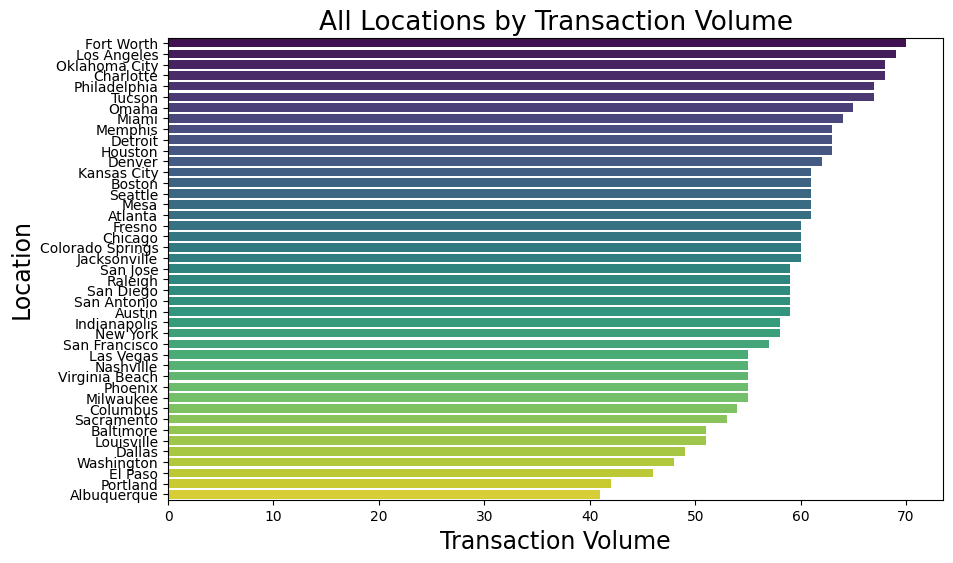

In [36]:
all_locations = df['Location'].value_counts().head(43)

plt.figure(figsize=(10,6))
sns.barplot(y=all_locations.index, x=all_locations.values, palette='viridis')
plt.title('All Locations by Transaction Volume', fontsize=19)
plt.xlabel('Transaction Volume', fontsize=17)
plt.ylabel('Location', fontsize=17)

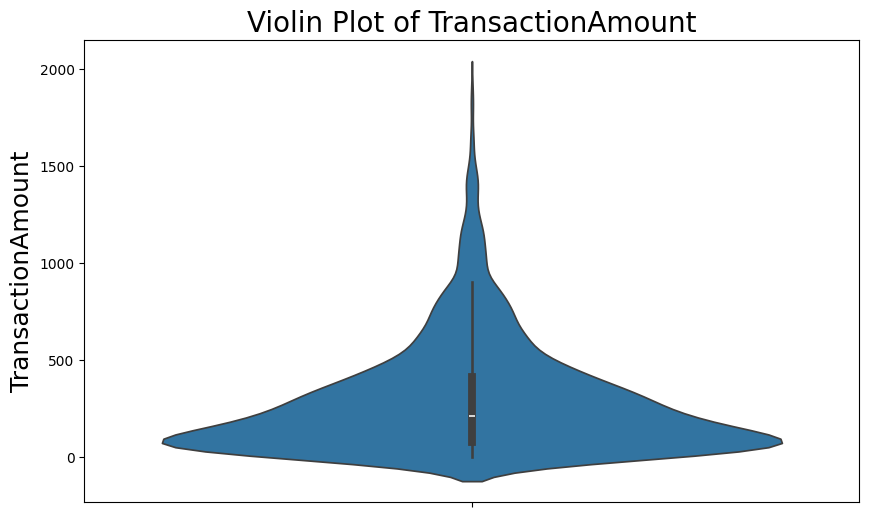

In [37]:
plt.figure(figsize=(10,6))
sns.violinplot(y='TransactionAmount', data=df)

plt.title('Violin Plot of TransactionAmount', fontsize=20)

plt.ylabel('TransactionAmount', fontsize=18)

plt.show()

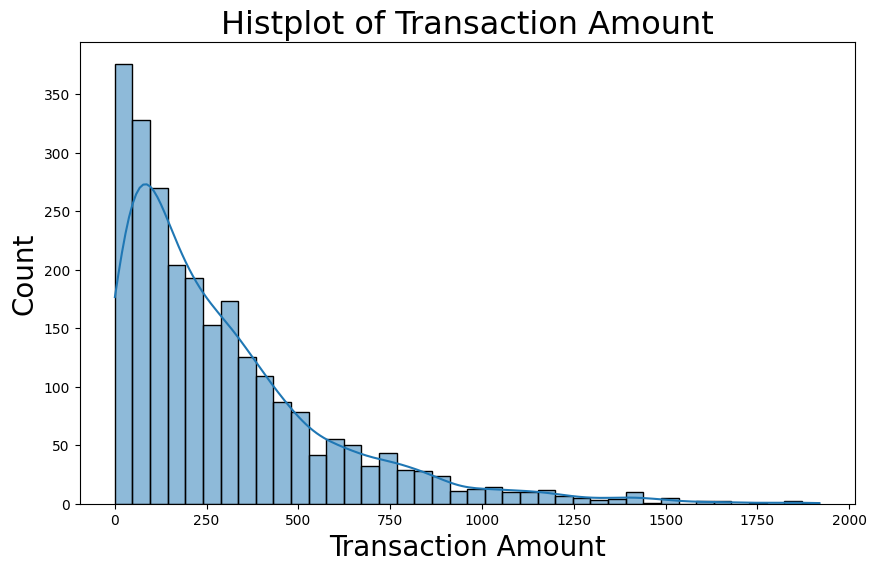

In [38]:
plt.figure(figsize=(10,6))

plt.xlabel("Transaction Amount", fontsize=20)
plt.ylabel("Count", fontsize=20)

plt.title("Histplot of Transaction Amount", fontsize=23)

sns.histplot(data=df, x="TransactionAmount", kde=True)

plt.show()

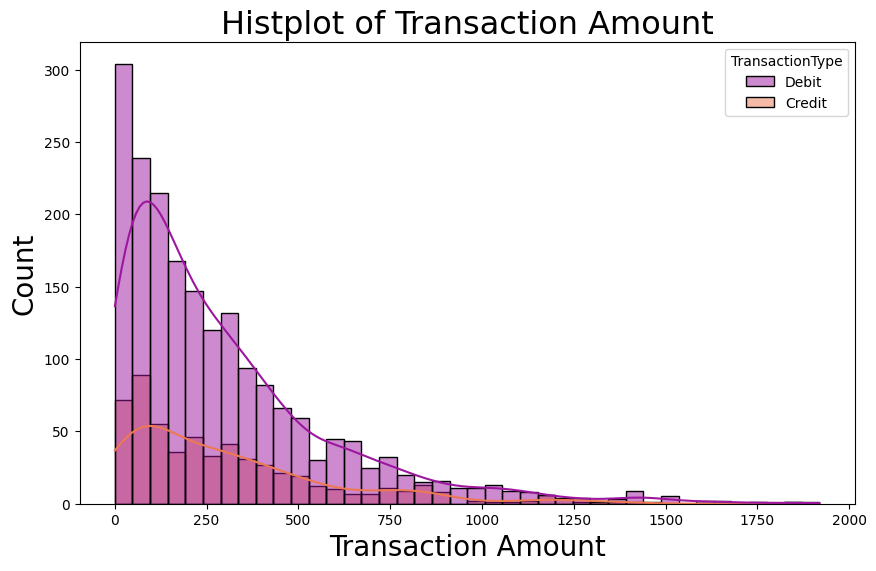

In [39]:
plt.figure(figsize=(10,6))

plt.xlabel("Transaction Amount", fontsize=20)
plt.ylabel("Count", fontsize=20)

plt.title("Histplot of Transaction Amount", fontsize=23)

sns.histplot(data=df, x="TransactionAmount", kde=True, hue='TransactionType', palette='plasma')

plt.show()

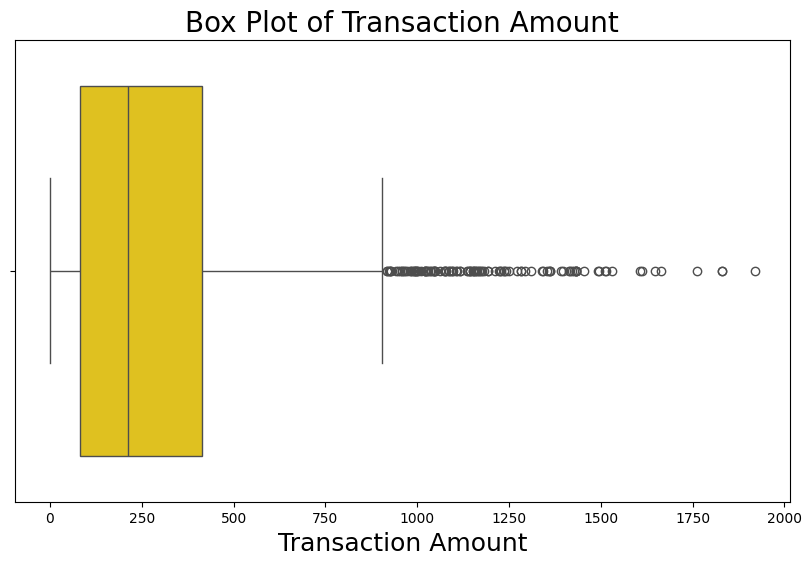

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['TransactionAmount'], color='gold')

plt.title('Box Plot of Transaction Amount', fontsize=20)
plt.xlabel('Transaction Amount', fontsize=18)

plt.show()

In [41]:
df['TransactionType'].value_counts()

TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

In [42]:
debitcard_counts = df[df['TransactionType']=='Debit']['TransactionType'].count()
creditcard_counts = df[df['TransactionType']=='Credit']['TransactionType'].count()

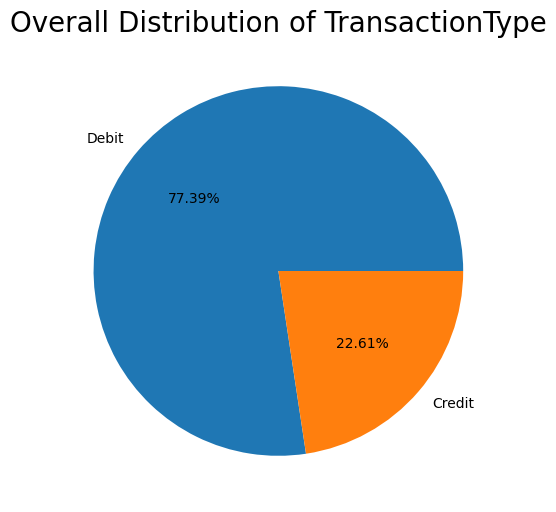

In [43]:
plt.figure(figsize=(10,6))

index_values = [debitcard_counts, creditcard_counts]
index_labels = ['Debit', 'Credit']

plt.pie(index_values, labels = index_labels, autopct='%2.2f%%')

plt.title('Overall Distribution of TransactionType', fontsize=20)

plt.show()

In [44]:
location_counts = df['Location'].value_counts()
location_counts

Location
Fort Worth          70
Los Angeles         69
Oklahoma City       68
Charlotte           68
Philadelphia        67
Tucson              67
Omaha               65
Miami               64
Memphis             63
Detroit             63
Houston             63
Denver              62
Kansas City         61
Boston              61
Seattle             61
Mesa                61
Atlanta             61
Fresno              60
Chicago             60
Colorado Springs    60
Jacksonville        60
San Jose            59
Raleigh             59
San Diego           59
San Antonio         59
Austin              59
Indianapolis        58
New York            58
San Francisco       57
Las Vegas           55
Nashville           55
Virginia Beach      55
Phoenix             55
Milwaukee           55
Columbus            54
Sacramento          53
Baltimore           51
Louisville          51
Dallas              49
Washington          48
El Paso             46
Portland            42
Albuquerque         41
Na

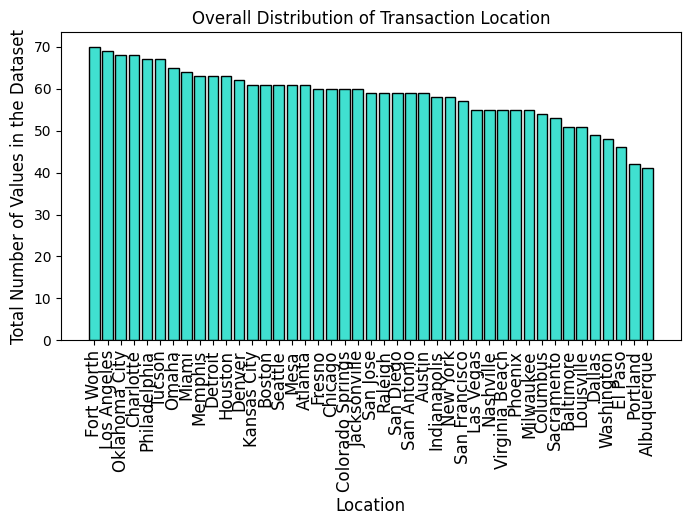

In [94]:
plt.figure(figsize=(8,4))
plt.bar(location_counts.index, location_counts.values, color='turquoise', edgecolor='black')
plt.xticks(location_counts.index, location_counts.index, rotation=90, fontsize=12)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Total Number of Values in the Dataset', fontsize=12)
plt.title('Overall Distribution of Transaction Location', fontsize=12)
plt.show()

In [46]:
df['DeviceID'].value_counts()

DeviceID
D000548    9
D000142    9
D000451    9
D000697    9
D000203    9
          ..
D000306    1
D000252    1
D000459    1
D000571    1
D000087    1
Name: count, Length: 681, dtype: int64

In [47]:
df['Channel'].value_counts()

Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

In [48]:
branch_counts = df[df['Channel']=='Branch']['Channel'].count()
atm_counts = df[df['Channel']=='ATM']['Channel'].count()
online_counts = df[df['Channel']=='Online']['Channel'].count()

branch_counts, atm_counts, online_counts

(np.int64(868), np.int64(833), np.int64(811))

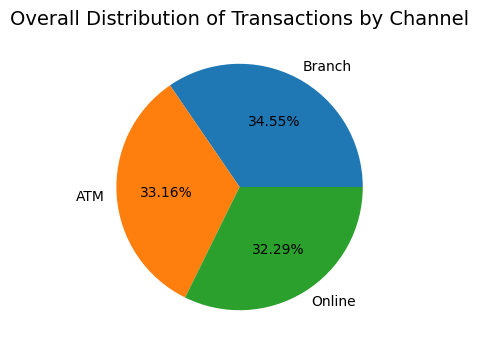

In [95]:
plt.figure(figsize=(8,4))

index_values = [branch_counts, atm_counts, online_counts]
index_labels = ['Branch', 'ATM', 'Online']

plt.pie(index_values, labels = index_labels, autopct='%2.2f%%')

plt.title('Overall Distribution of Transactions by Channel', fontsize=14)

plt.show()

In [50]:
from datetime import datetime

TransactionDay
2023-01-02    19
2023-01-03     9
2023-01-04     4
2023-01-05     8
2023-01-06     7
              ..
2023-12-26     5
2023-12-27     4
2023-12-28     7
2023-12-29     9
2024-01-01    13
Length: 261, dtype: int64


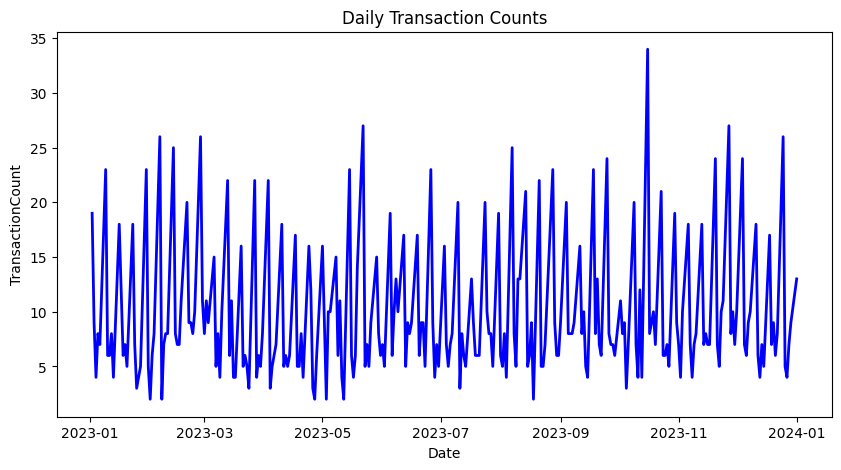

In [52]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionDay'] = df['TransactionDate'].dt.date
daily_counts = df.groupby('TransactionDay').size() #count gives count of each column in the dataframe
print(daily_counts) 
plt.figure(figsize=(10,5))
daily_counts.plot(title='Daily Transaction Counts', color='blue', linewidth=2)
plt.xlabel('Date')
plt.ylabel('TransactionCount')
plt.show()

0         Tuesday
1         Tuesday
2          Monday
3          Friday
4          Monday
          ...    
2507    Wednesday
2508    Wednesday
2509       Monday
2510       Friday
2511      Tuesday
Name: DayOfWeek, Length: 2512, dtype: object


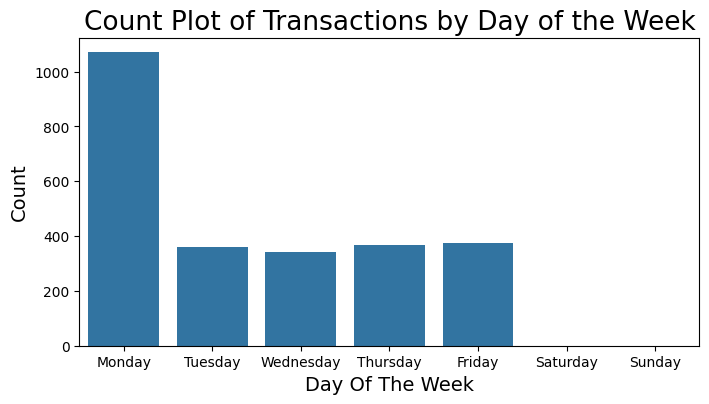

In [96]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
print(df['DayOfWeek'])
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='DayOfWeek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Count Plot of Transactions by Day of the Week', fontsize=19)
plt.xlabel('Day Of The Week', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

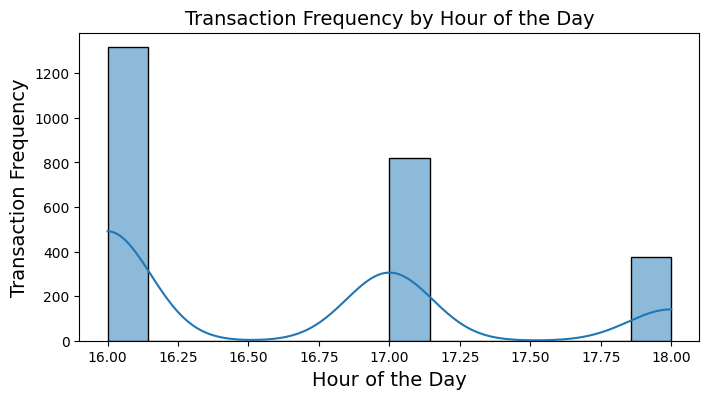

In [97]:
df['Hour'] = df['TransactionDate'].dt.hour
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Hour', kde=True, palette='plasma') #optionally you can set bins=24
plt.title('Transaction Frequency by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Transaction Frequency', fontsize=14)
plt.show()

In [58]:
df['CustomerAge'].value_counts()

CustomerAge
27    87
26    86
25    73
28    68
21    64
      ..
77    19
73    19
80    17
74    16
71    16
Name: count, Length: 63, dtype: int64

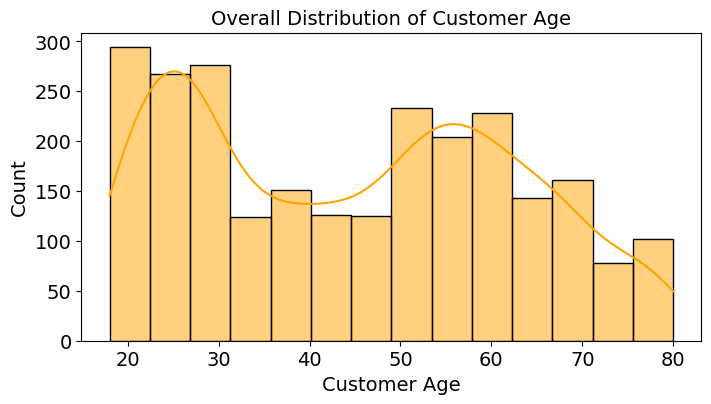

In [99]:
plt.figure(figsize=(8,4))

plt.xlabel('Customer Age', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.title('Overall Distribution of Customer Age', fontsize=14)

sns.histplot(data = df, x=df['CustomerAge'], kde=True, color='orange')

plt.show()

In [61]:
customer_occupation_counts = df['CustomerOccupation'].value_counts()
customer_occupation_counts

CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64

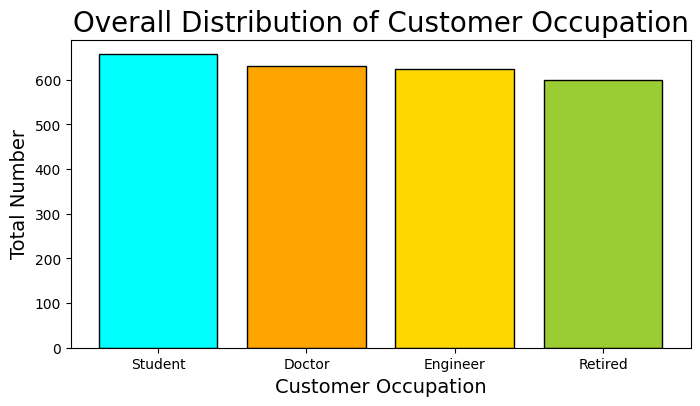

In [100]:
plt.figure(figsize=(8,4))

colors=['aqua', 'orange', 'gold', 'yellowgreen']

plt.bar(customer_occupation_counts.index, customer_occupation_counts.values, color=colors[:len(customer_occupation_counts)], edgecolor='black')

plt.xlabel('Customer Occupation', fontsize=14)
plt.ylabel('Total Number', fontsize=14)

plt.title('Overall Distribution of Customer Occupation', fontsize=20)

plt.show()

In [63]:
student_counts = df[df['CustomerOccupation']=='Student']['CustomerOccupation'].count()
doctor_counts = df[df['CustomerOccupation']=='Doctor']['CustomerOccupation'].count()
engineer_counts = df[df['CustomerOccupation']=='Engineer']['CustomerOccupation'].count()
retired_counts = df[df['CustomerOccupation']=='Retired']['CustomerOccupation'].count()

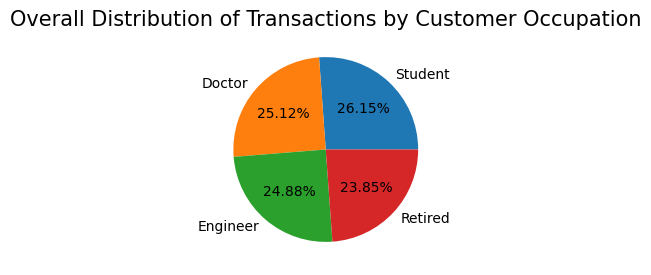

In [66]:
plt.figure(figsize=(8,3))
index_values = [student_counts, doctor_counts, engineer_counts, retired_counts]
index_labels = ['Student', 'Doctor', 'Engineer', 'Retired']
plt.pie(index_values, labels = index_labels, autopct='%2.2f%%')
plt.title('Overall Distribution of Transactions by Customer Occupation', fontsize=15)
plt.show()

In [67]:
df['AccountBalance'].value_counts()

AccountBalance
7707.96     2
1400.04     2
131.25      1
5112.21     1
13758.91    1
           ..
3634.67     1
673.35      1
2686.52     1
1772.06     1
6863.02     1
Name: count, Length: 2510, dtype: int64

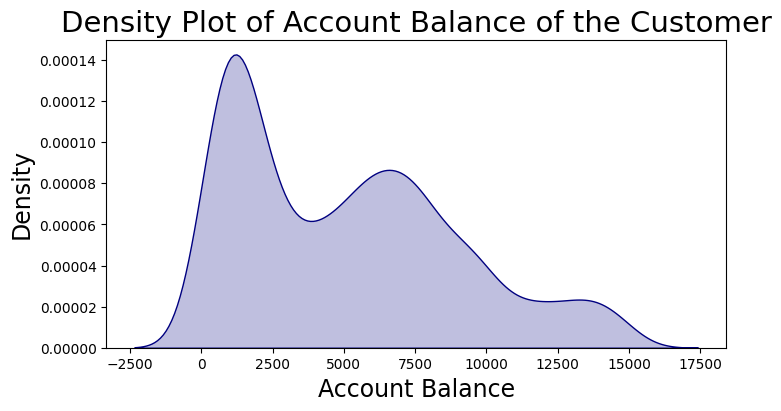

In [68]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='AccountBalance', shade=True, color='navy')

plt.xlabel('Account Balance', fontsize=17)
plt.ylabel('Density', fontsize=17)

plt.title('Density Plot of Account Balance of the Customer', fontsize=21)

plt.show()

In [69]:
from datetime import datetime

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['Hour of Transaction'] = df['TransactionDate'].dt.hour

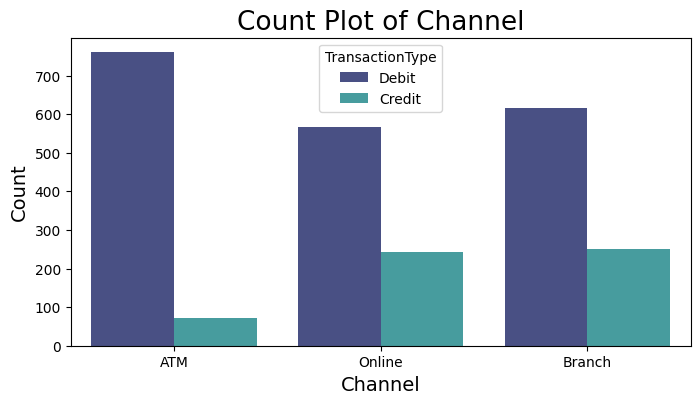

In [70]:
plt.figure(figsize=(8,4))

sns.countplot(data=df, x='Channel', hue='TransactionType', palette='mako')

plt.xlabel('Channel', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.title('Count Plot of Channel', fontsize=19)

plt.show()

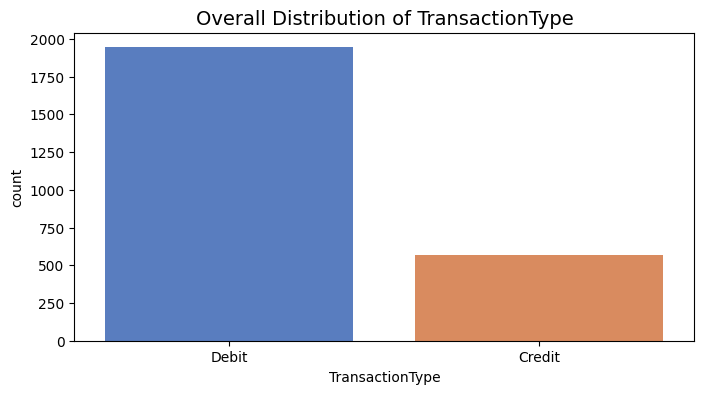

In [71]:
plt.figure(figsize=(8,4))

sns.countplot(data=df, x='TransactionType', palette='muted')

plt.title('Overall Distribution of TransactionType', fontsize=14)

plt.show()

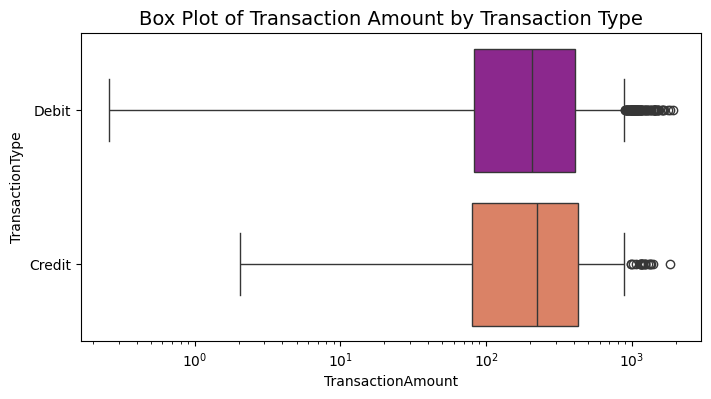

In [72]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df, x=df['TransactionAmount'], y=df['TransactionType'], palette='plasma')
plt.xscale('log') #Log scale to show outliers
plt.title('Box Plot of Transaction Amount by Transaction Type', fontsize=14)

plt.show()

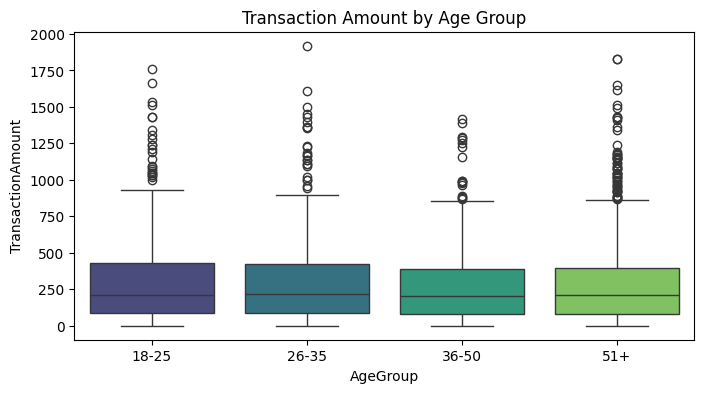

In [73]:
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=[0,25,35,50,100], labels=['18-25', '26-35', '36-50', '51+'])
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='AgeGroup', y='TransactionAmount', palette='viridis')
plt.title('Transaction Amount by Age Group')
plt.show()

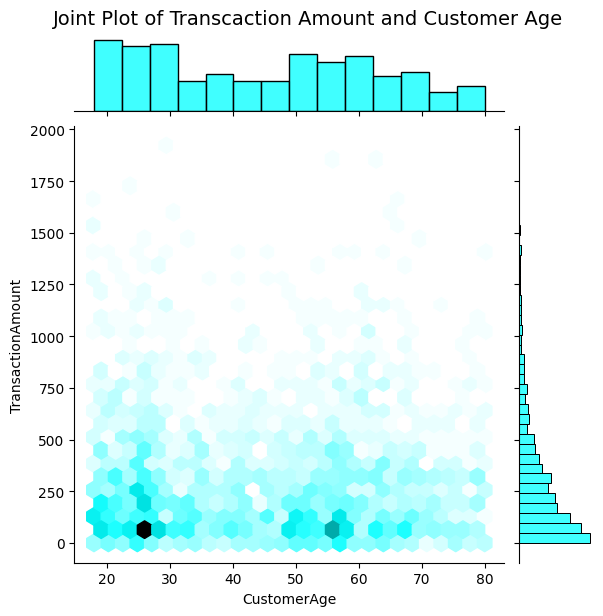

In [74]:
sns.jointplot(x='CustomerAge', y='TransactionAmount', data=df, kind='hex', color='aqua')
plt.suptitle('Joint Plot of Transcaction Amount and Customer Age', y=1.02, fontsize=14)
plt.show()

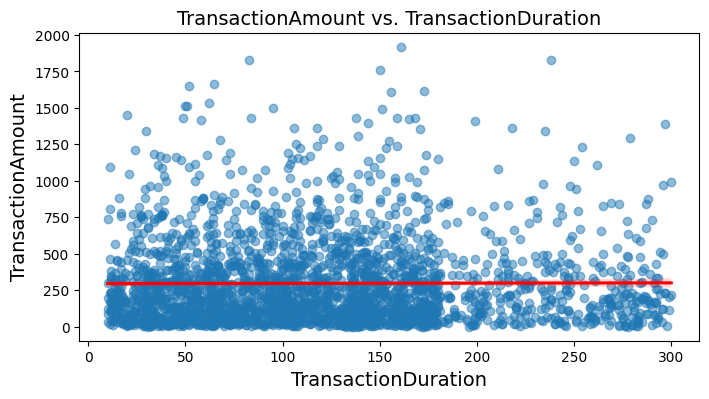

In [76]:
plt.figure(figsize=(8,4))
sns.regplot(x='TransactionDuration', y='TransactionAmount', data=df, scatter_kws={'alpha':0.5}, line_kws = {'color':'red'})
plt.title('TransactionAmount vs. TransactionDuration', fontsize=14)
plt.xlabel('TransactionDuration', fontsize=14)
plt.ylabel('TransactionAmount', fontsize=14)
plt.show()

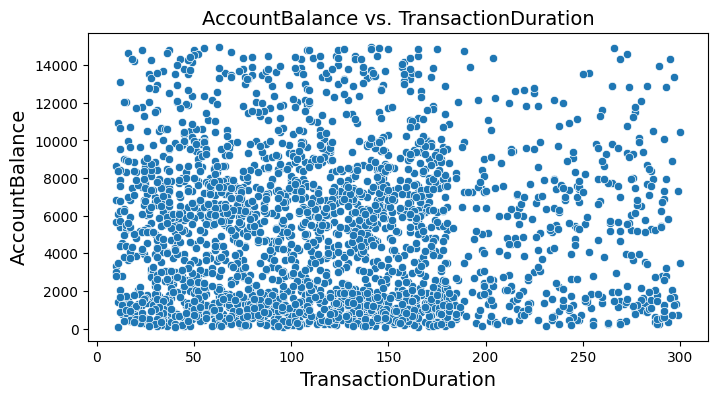

In [77]:
plt.figure(figsize=(8,4))
sns.scatterplot(y='AccountBalance', x='TransactionDuration', data=df)
plt.xlabel('TransactionDuration', fontsize=14)
plt.ylabel('AccountBalance', fontsize=14)
plt.title('AccountBalance vs. TransactionDuration', fontsize=14)
plt.show()

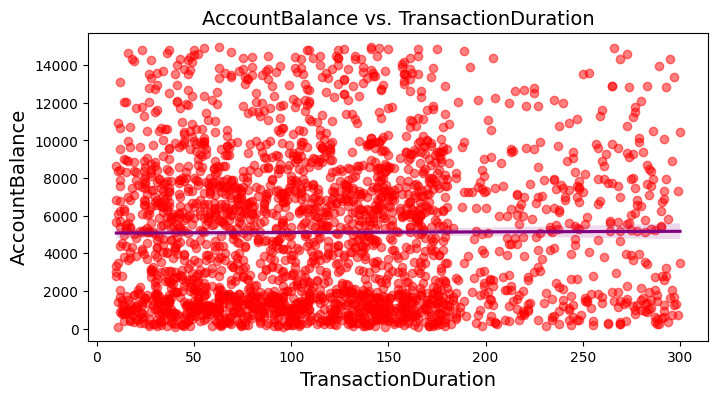

In [78]:
plt.figure(figsize=(8,4))
sns.regplot(y='AccountBalance', x='TransactionDuration', data=df, color='red', scatter_kws={'alpha':0.5}, line_kws = {'color':'purple'})
plt.xlabel('TransactionDuration', fontsize=14)
plt.ylabel('AccountBalance', fontsize=14)
plt.title('AccountBalance vs. TransactionDuration', fontsize=14)
plt.show()

<Figure size 800x400 with 0 Axes>

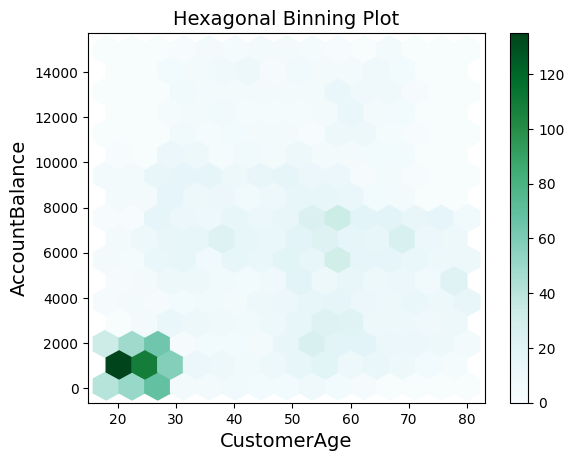

In [82]:
plt.figure(figsize=(8,4))

df.plot(kind='hexbin', x='CustomerAge', y='AccountBalance', gridsize=14)

plt.title('Hexagonal Binning Plot', fontsize=14)

plt.xlabel('CustomerAge', fontsize=14)
plt.ylabel('AccountBalance', fontsize=14)

plt.show()

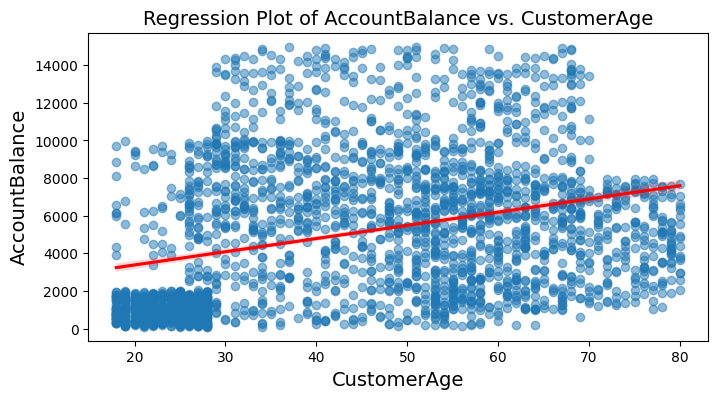

In [80]:
plt.figure(figsize=(8,4))

sns.regplot(x='CustomerAge', y='AccountBalance', data=df, scatter_kws = {'alpha' : 0.5}, line_kws={'color' : 'red'})

plt.title('Regression Plot of AccountBalance vs. CustomerAge', fontsize=14)

plt.xlabel('CustomerAge', fontsize=14)
plt.ylabel('AccountBalance', fontsize=14)

plt.show()

<Figure size 800x600 with 0 Axes>

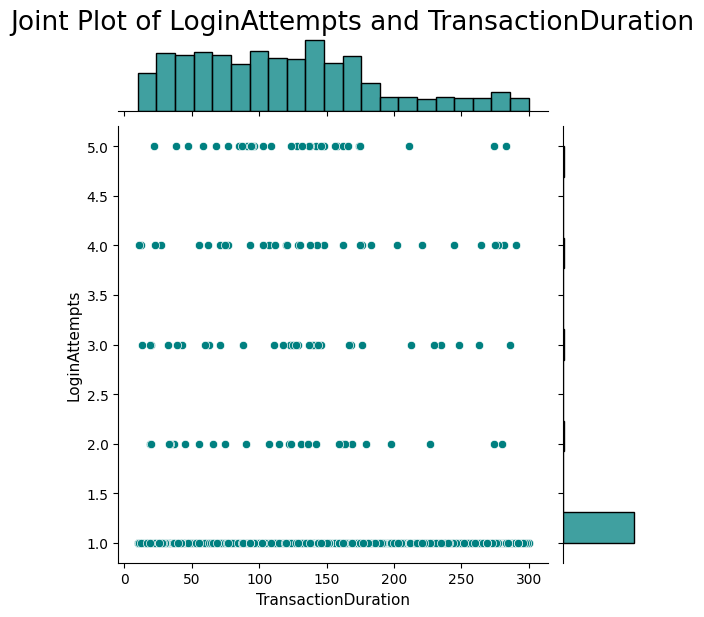

In [81]:
plt.figure(figsize=(8,6))
sns.jointplot(y='LoginAttempts', x='TransactionDuration', data=df, color='teal')
plt.xlabel('TransactionDuration', fontsize=11)
plt.ylabel('LoginAttempts', fontsize=11)
plt.suptitle('Joint Plot of LoginAttempts and TransactionDuration', y=1.02, fontsize=19)
plt.show()

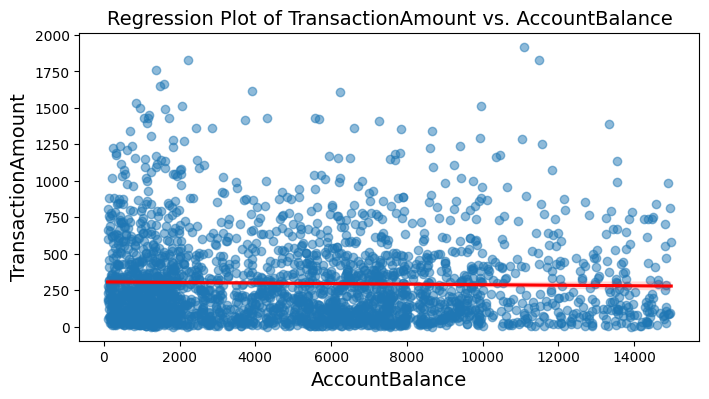

In [84]:
plt.figure(figsize=(8,4))

sns.regplot(y='TransactionAmount', x='AccountBalance', data=df, scatter_kws = {'alpha':0.5}, line_kws={'color':'red'})

plt.title('Regression Plot of TransactionAmount vs. AccountBalance', fontsize=14)

plt.xlabel('AccountBalance', fontsize=14)
plt.ylabel('TransactionAmount', fontsize=14)

plt.show()

<Figure size 800x400 with 0 Axes>

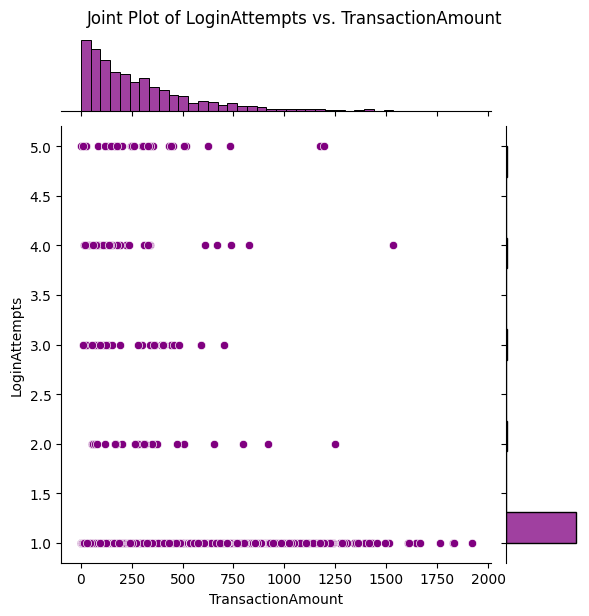

In [85]:
plt.figure(figsize=(8,4))

sns.jointplot(x='TransactionAmount', y='LoginAttempts', data=df, color='purple')

plt.suptitle('Joint Plot of LoginAttempts vs. TransactionAmount', y=1.02)

plt.show()

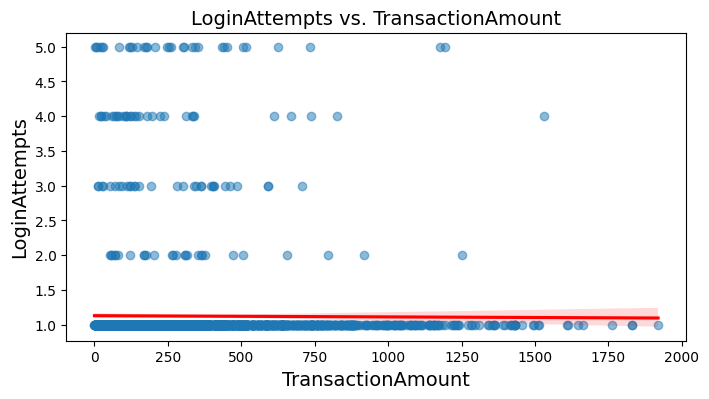

In [86]:
plt.figure(figsize=(8,4))

sns.regplot(x='TransactionAmount', y='LoginAttempts', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('TransactionAmount', fontsize=14)
plt.ylabel('LoginAttempts', fontsize=14)

plt.title('LoginAttempts vs. TransactionAmount', fontsize=14)

plt.show()

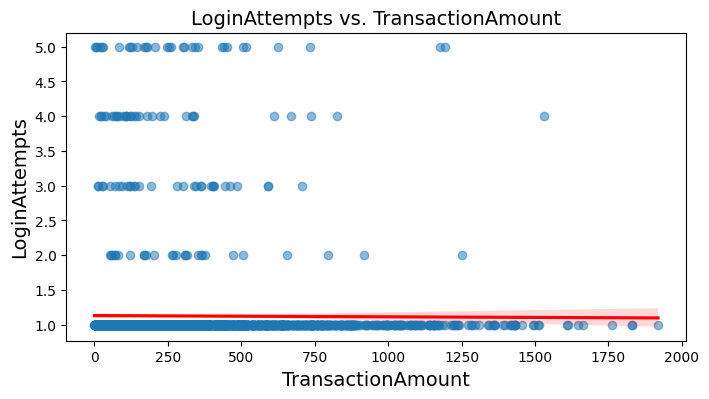

In [87]:
plt.figure(figsize=(8,4))

sns.regplot(x='TransactionAmount', y='LoginAttempts', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('TransactionAmount', fontsize=14)
plt.ylabel('LoginAttempts', fontsize=14)

plt.title('LoginAttempts vs. TransactionAmount', fontsize=14)

plt.show()

Text(0.5, 1.02, 'LoginAttempts vs. AccountBalance')

<Figure size 800x400 with 0 Axes>

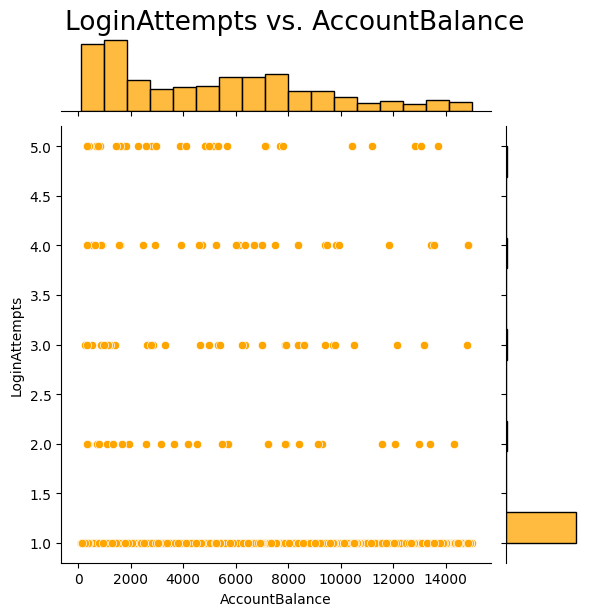

In [88]:
plt.figure(figsize=(8,4))

sns.jointplot(x='AccountBalance', y='LoginAttempts', data=df, color='orange')

plt.suptitle('LoginAttempts vs. AccountBalance', y=1.02, fontsize=19)

<Axes: xlabel='TransactionDuration', ylabel='TransactionAmount'>

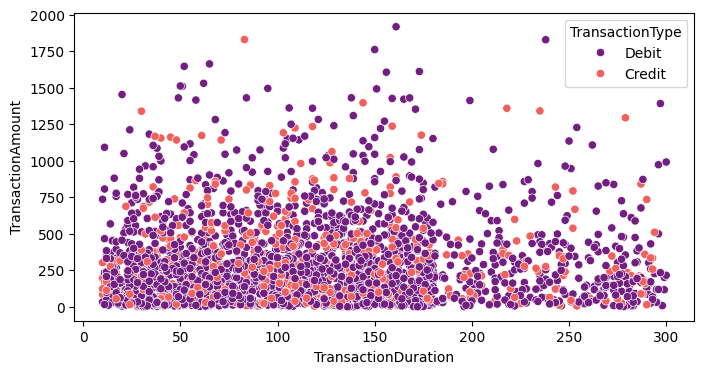

In [89]:
plt.figure(figsize=(8,4))
sns.scatterplot(x='TransactionDuration', y='TransactionAmount', data=df, hue='TransactionType', palette='magma')

In [90]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate',
       'TransactionDay', 'DayOfWeek', 'Hour', 'Hour of Transaction',
       'AgeGroup'],
      dtype='object')

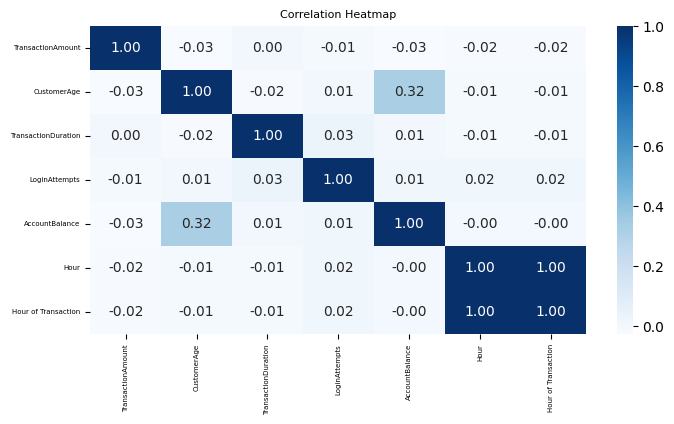

In [91]:
plt.figure(figsize=(8,4))
# corr_matrix = df.drop(columns=['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'MerchantID', 'PreviousTransactionDate', 'Channel', 'IP Address', 'CustomerOccupation']).corr()
numeric_columns = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.xticks(rotation=90, fontsize=5)
plt.yticks(fontsize=5)
plt.title('Correlation Heatmap', fontsize=8)
plt.show()

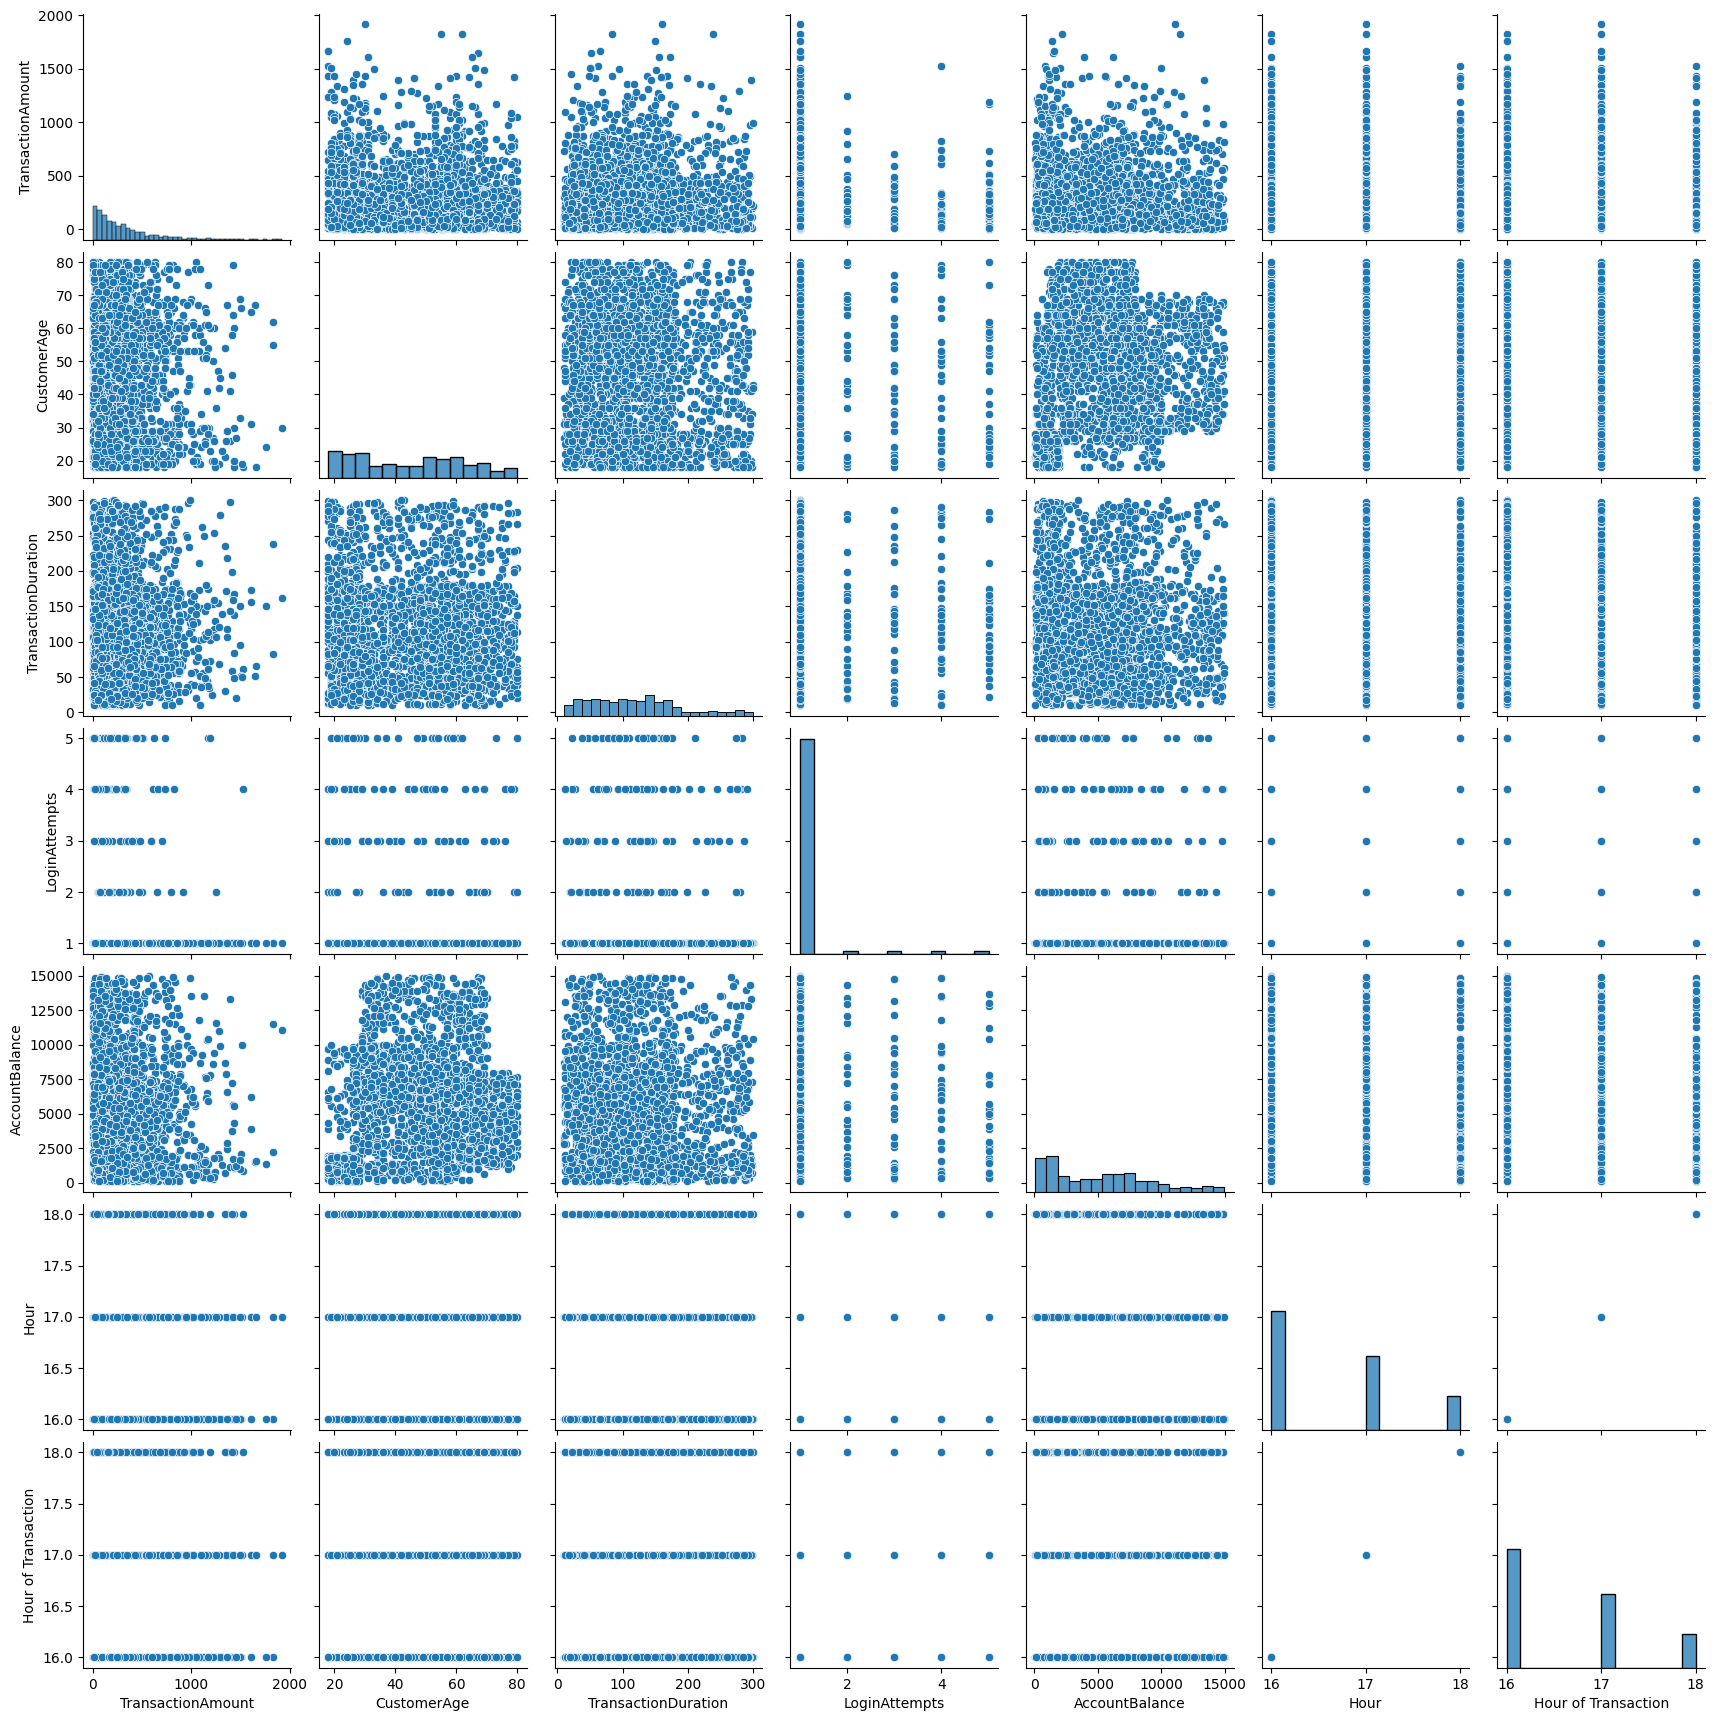

In [92]:
sns.pairplot(df)